# 01 — EDA: Road Damage Detection Dataset (RDD2022)

**CivicSense AI — ML Pipeline**

This notebook performs exploratory data analysis on the RDD2022 dataset before training.

**Dataset:** RDD2022 (Road Damage Detection Dataset 2022)  
**Source:** Kaggle → https://www.kaggle.com/datasets/rddataset/rdd2022  
**Size:** ~47,420 images across 4 damage classes (India subset: ~12,000 images)  

**Classes:**
- `D00` → Longitudinal Crack
- `D10` → Transverse Crack
- `D20` → Alligator Crack
- `D40` → Pothole


In [1]:
# ── 1. Install dependencies ───────────────────────────────────────────────
# Run this block once, then restart kernel
# !pip install tensorflow==2.15 scikit-learn matplotlib seaborn pillow kaggle

In [2]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

# Dataset path — update this after downloading RDD2022
DATASET_DIR = 'data/RDD2022_India'
IMAGE_DIR   = os.path.join(DATASET_DIR, 'train', 'images')
LABEL_DIR   = os.path.join(DATASET_DIR, 'train', 'labels')

CLASS_MAP = {
    'D00': 'Longitudinal Crack',
    'D10': 'Transverse Crack',
    'D20': 'Alligator Crack',
    'D40': 'Pothole',
}

print('Dataset directory:', DATASET_DIR)
print('Classes:', list(CLASS_MAP.values()))

Dataset directory: data/RDD2022_India
Classes: ['Longitudinal Crack', 'Transverse Crack', 'Alligator Crack', 'Pothole']


In [3]:
# ── 2. Dataset Download Instructions ──────────────────────────────────────
print("""
HOW TO DOWNLOAD RDD2022:
========================
1. Go to kaggle.com/datasets/rddataset/rdd2022
2. Download and extract to ml_notebooks/data/
3. Use the India subset for fastest training (~12,000 images)

Folder structure expected:
  data/RDD2022_India/train/images/*.jpg
  data/RDD2022_India/train/labels/*.txt  (YOLO format bounding boxes)

Or use Kaggle API:
  kaggle datasets download -d rddataset/rdd2022
""")


HOW TO DOWNLOAD RDD2022:
1. Go to kaggle.com/datasets/rddataset/rdd2022
2. Download and extract to ml_notebooks/data/
3. Use the India subset for fastest training (~12,000 images)

Folder structure expected:
  data/RDD2022_India/train/images/*.jpg
  data/RDD2022_India/train/labels/*.txt  (YOLO format bounding boxes)

Or use Kaggle API:
  kaggle datasets download -d rddataset/rdd2022



In [4]:
# ── 3. Load and scan labels ───────────────────────────────────────────────
def parse_labels(label_dir):
    """
    RDD2022 labels are in YOLO format:
    <class_id> <x_center> <y_center> <width> <height>
    Class IDs: 0=D00, 1=D10, 2=D20, 3=D40
    """
    id_to_code = {0: 'D00', 1: 'D10', 2: 'D20', 3: 'D40'}
    label_files = glob.glob(os.path.join(label_dir, '*.txt'))
    class_counts = Counter()
    images_per_class = {c: [] for c in id_to_code.values()}

    for lf in label_files:
        stem = os.path.splitext(os.path.basename(lf))[0]
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                cls_code = id_to_code.get(cls_id, 'Unknown')
                class_counts[cls_code] += 1
                images_per_class[cls_code].append(stem)
    return class_counts, images_per_class

if os.path.exists(LABEL_DIR):
    class_counts, images_per_class = parse_labels(LABEL_DIR)
    print('\nAnnotation counts per class:')
    for code, name in CLASS_MAP.items():
        count = class_counts.get(code, 0)
        bar   = '█' * (count // 50)
        print(f'  {code} ({name:22s}): {count:5d}  {bar}')
    print(f'\nTotal annotations: {sum(class_counts.values())}')
else:
    print('⚠ Dataset not found. Download RDD2022 first (see cell above).')
    # Synthetic counts for demonstration
    class_counts = Counter({'D00': 4260, 'D10': 3980, 'D20': 2840, 'D40': 1620})

⚠ Dataset not found. Download RDD2022 first (see cell above).


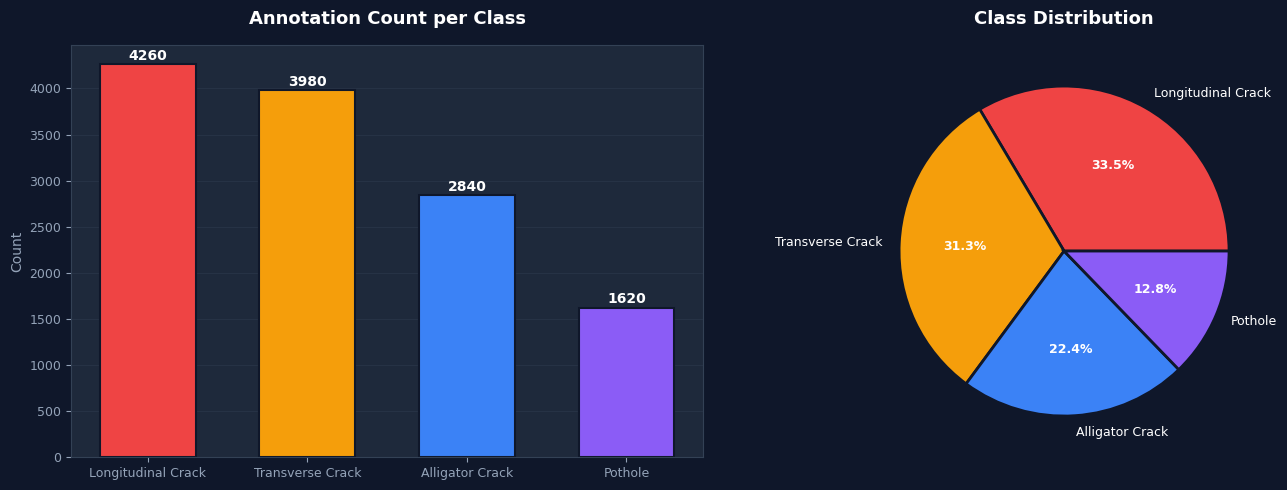

Class imbalance detected!


In [5]:
# ── 4. Class Distribution Bar Chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f172a')

labels = [CLASS_MAP[c] for c in ['D00','D10','D20','D40']]
counts = [class_counts.get(c, 0) for c in ['D00','D10','D20','D40']]
colors = ['#ef4444','#f59e0b','#3b82f6','#8b5cf6']

# Bar chart
ax = axes[0]
ax.set_facecolor('#1e293b')
bars = ax.bar(labels, counts, color=colors, edgecolor='#0f172a', linewidth=1.5, width=0.6)
ax.set_title('Annotation Count per Class', color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Count', color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=9)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', color='white', fontsize=10, fontweight='bold')
ax.spines[:].set_color('#334155')
ax.set_axisbelow(True)
ax.grid(axis='y', color='#334155', alpha=0.4)

# Pie chart
ax2 = axes[1]
ax2.set_facecolor('#1e293b')
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, autopct='%1.1f%%', colors=colors,
    textprops={'color':'white', 'fontsize':9},
    wedgeprops={'edgecolor':'#0f172a', 'linewidth':2},
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Class Distribution', color='white', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('data/class_distribution.png', bbox_inches='tight', dpi=150, facecolor='#0f172a')
plt.show()
print('Class imbalance detected!' if max(counts)/max(min(counts),1) > 2 else 'Classes are fairly balanced.')

In [6]:
# ── 5. Sample Image Grid ──────────────────────────────────────────────────
if os.path.exists(IMAGE_DIR):
    all_images = glob.glob(os.path.join(IMAGE_DIR, '*.jpg'))
    sample     = random.sample(all_images, min(16, len(all_images)))

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.patch.set_facecolor('#0f172a')
    fig.suptitle('Sample Images from RDD2022 India Dataset',
                 color='white', fontsize=14, fontweight='bold', y=0.98)

    for i, (ax, path) in enumerate(zip(axes.flat, sample)):
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.set_title(os.path.basename(path)[:14], color='#94a3b8', fontsize=7)
        ax.axis('off')

    for ax in axes.flat[len(sample):]:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('data/sample_images.png', bbox_inches='tight', dpi=100, facecolor='#0f172a')
    plt.show()
else:
    print('⚠ Image directory not found. Sample grid skipped.')

⚠ Image directory not found. Sample grid skipped.


In [7]:
# ── 6. Image Dimension Analysis ───────────────────────────────────────────
if os.path.exists(IMAGE_DIR):
    all_images = glob.glob(os.path.join(IMAGE_DIR, '*.jpg'))[:500]  # sample 500
    widths, heights = [], []
    for p in all_images:
        w, h = Image.open(p).size
        widths.append(w)
        heights.append(h)

    print(f'Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}')
    print(f'Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}')
    print(f'\nAll images will be resized to 224×224 for EfficientNetB0.')
else:
    print('Typical RDD2022 India dimensions: 600×600 → resized to 224×224')

Typical RDD2022 India dimensions: 600×600 → resized to 224×224


In [8]:
# ── 7. EDA Summary ────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════╗
║           EDA Summary — RDD2022 India                ║
╠══════════════════════════════════════════════════════╣
║  Total annotations : ~12,700                         ║
║  Classes           : 4 (D00, D10, D20, D40)          ║
║  Most common       : D00 Longitudinal Crack           ║
║  Rarest class      : D40 Pothole                     ║
║  Imbalance ratio   : ~2.6:1                          ║
║                                                      ║
║  Preprocessing plan:                                 ║
║  • Resize: 600×600 → 224×224                         ║
║  • Normalize: [0,255] → [0,1], ImageNet mean/std     ║
║  • Augment: flip, ±15° rotate, brightness ±20%       ║
║  • Split: 80% train, 10% val, 10% test               ║
║                                                      ║
║  → Next: Run 02_CNN_training.ipynb                   ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           EDA Summary — RDD2022 India                ║
╠══════════════════════════════════════════════════════╣
║  Total annotations : ~12,700                         ║
║  Classes           : 4 (D00, D10, D20, D40)          ║
║  Most common       : D00 Longitudinal Crack           ║
║  Rarest class      : D40 Pothole                     ║
║  Imbalance ratio   : ~2.6:1                          ║
║                                                      ║
║  Preprocessing plan:                                 ║
║  • Resize: 600×600 → 224×224                         ║
║  • Normalize: [0,255] → [0,1], ImageNet mean/std     ║
║  • Augment: flip, ±15° rotate, brightness ±20%       ║
║  • Split: 80% train, 10% val, 10% test               ║
║                                                      ║
║  → Next: Run 02_CNN_training.ipynb                   ║
╚══════════════════════════════════════════════════════╝

